# COVID-19 Exercise - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 3:30.** You drive a coding agent (Codex, Claude Code, or Antigravity
CLI) to detect when a COVID-19 outbreak is taking off, and keep the judgment. For each
step: read the goal, paste the prompt, run the code, check the result.

> Each prompt produces roughly the matching cell in the **Lane B** notebook. Data:
> `covid_traces_WA.csv`.


## Step 0: load and look

> *Load covid_traces_WA.csv (daily, Washington State). In a 6-panel plot show new_cases*
> *and the five digital traces (upToDate, cdc_ili, Twitter_RelatedTweets, google_fever,*
> *Kinsa) over time. Which look leading vs lagging relative to cases?*


/tmp/ipykernel_39309/263681978.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


Removed 693 days with a zero or missing digital trace; analyzing 46 dates from 2020-03-03 to 2020-04-26.


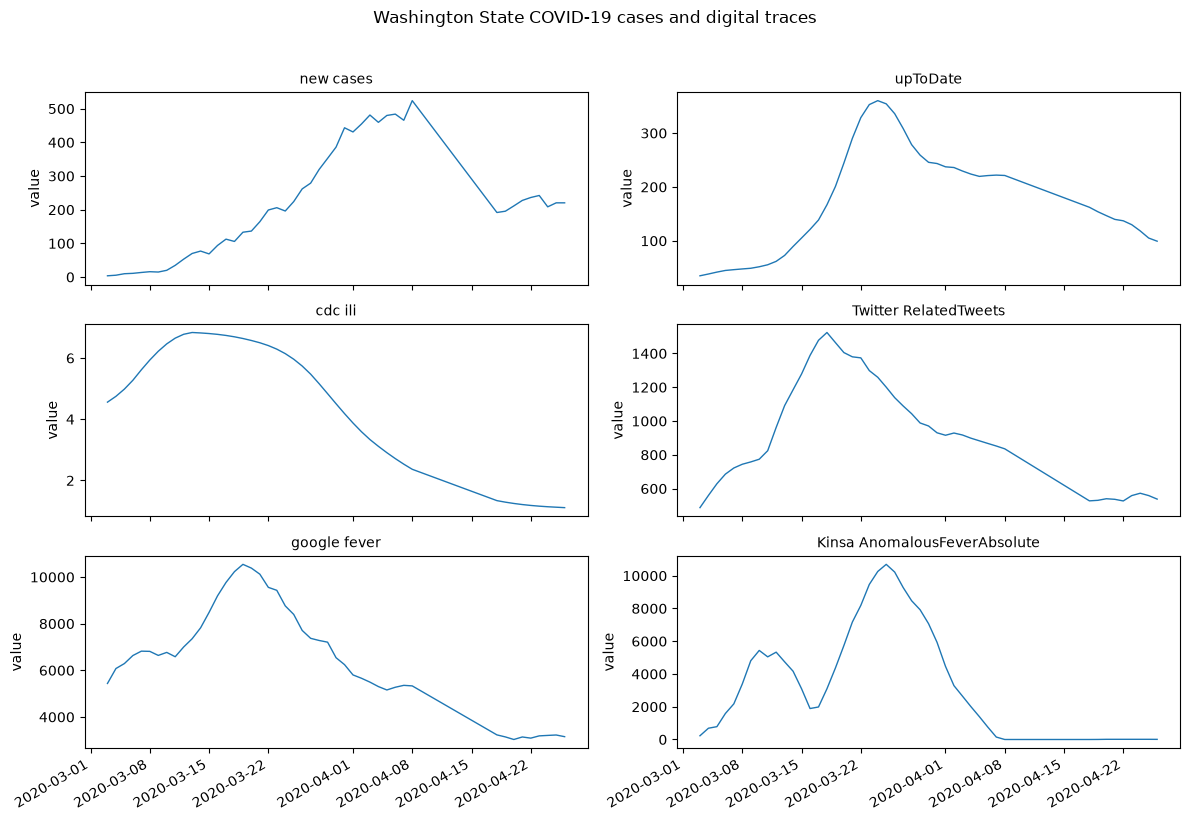

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

CANDIDATES = [
    '../data/covid_traces_WA.csv',
    'data/covid_traces_WA.csv',
    './covid_traces_WA.csv',
    'day2-1530-covid-exercise/data/covid_traces_WA.csv',
]
path = next((candidate for candidate in CANDIDATES if os.path.exists(candidate)), CANDIDATES[0])
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date'])

TRACES = [
    'new_cases',
    'upToDate',
    'cdc_ili',
    'Twitter_RelatedTweets',
    'google_fever',
    'Kinsa_AnomalousFeverAbsolute',
]

# Use the common period where every digital trace is observed and positive.
# A zero in one of these source feeds denotes unavailable/zero-filled data here.
DIGITAL_TRACES = TRACES[1:]
valid_digital_data = df[DIGITAL_TRACES].notna().all(axis=1) & df[DIGITAL_TRACES].gt(0).all(axis=1)
removed_days = (~valid_digital_data).sum()
df = df.loc[valid_digital_data].copy()
print(f'Removed {removed_days} days with a zero or missing digital trace; analyzing {len(df)} dates from '
      f'{df["date"].min().date()} to {df["date"].max().date()}.')

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for ax, trace in zip(axes.ravel(), TRACES):
    ax.plot(df['date'], df[trace], color='C0', linewidth=1)
    ax.set_title(trace.replace('_', ' '), fontsize=10)
    ax.set_ylabel('value')

fig.suptitle('Washington State COVID-19 cases and digital traces', y=1.02)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Step 1: the growth factor alpha

> *For new_cases, slide an 11-day window: in each window regress the last 10 days on the*
> *previous 10 with NO intercept, and store the slope as alpha for that day. Then make a*
> *3-panel plot: cases, alpha with a line at 1, and a 0/1 flag for alpha > 1. Explain what*
> *alpha means.*


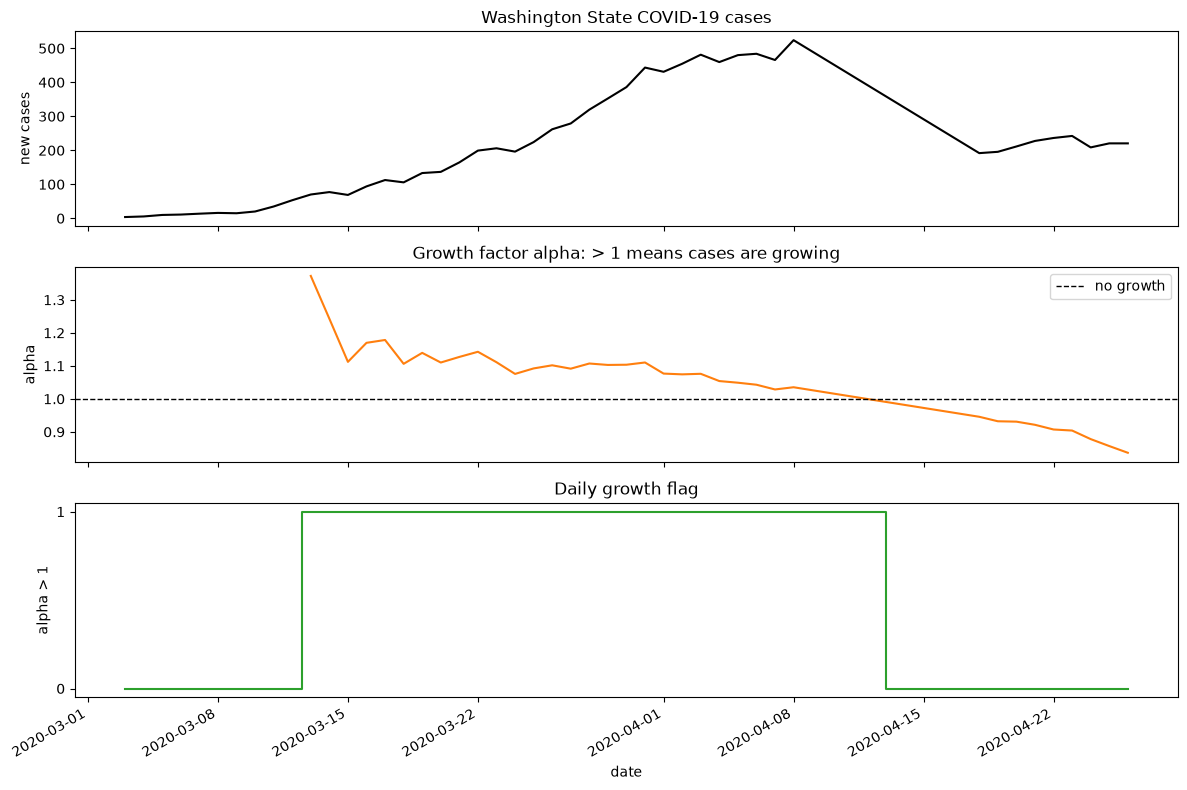

In [2]:
import numpy as np

def growth_alpha(values, window=10):
    """Estimate the day-to-day multiplicative growth factor in a rolling window."""
    values = np.asarray(values, dtype=float)
    alpha = np.full(len(values), np.nan)
    for day in range(window, len(values)):
        previous = values[day - window:day]
        current = values[day - window + 1:day + 1]
        denominator = np.dot(previous, previous)
        if denominator > 0:
            alpha[day] = np.dot(previous, current) / denominator
    return alpha

alpha_cases = growth_alpha(df['new_cases'])
growing_cases = (alpha_cases > 1).astype(int)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['date'], df['new_cases'], color='black')
axes[0].set_title('Washington State COVID-19 cases')
axes[0].set_ylabel('new cases')

axes[1].plot(df['date'], alpha_cases, color='C1')
axes[1].axhline(1, color='black', linestyle='--', linewidth=1, label='no growth')
axes[1].set_title('Growth factor alpha: > 1 means cases are growing')
axes[1].set_ylabel('alpha')
axes[1].legend()

axes[2].step(df['date'], growing_cases, where='mid', color='C2')
axes[2].set_title('Daily growth flag')
axes[2].set_ylabel('alpha > 1')
axes[2].set_yticks([0, 1])
axes[2].set_xlabel('date')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Step 2: detect outbreak starts

> *When alpha > 1 for 10 consecutive days, mark that 10th day as an outbreak start (only*
> *the first such day); when alpha < 1 for 10 consecutive days the outbreak is over and a*
> *later run can start a new one. Implement it, print the detected start dates, and mark*
> *them on the case-count plot.*

**Your check:** do the marks line up with where you said outbreaks start in Step 0?


Detected case outbreak starts:
 - 2020-03-22


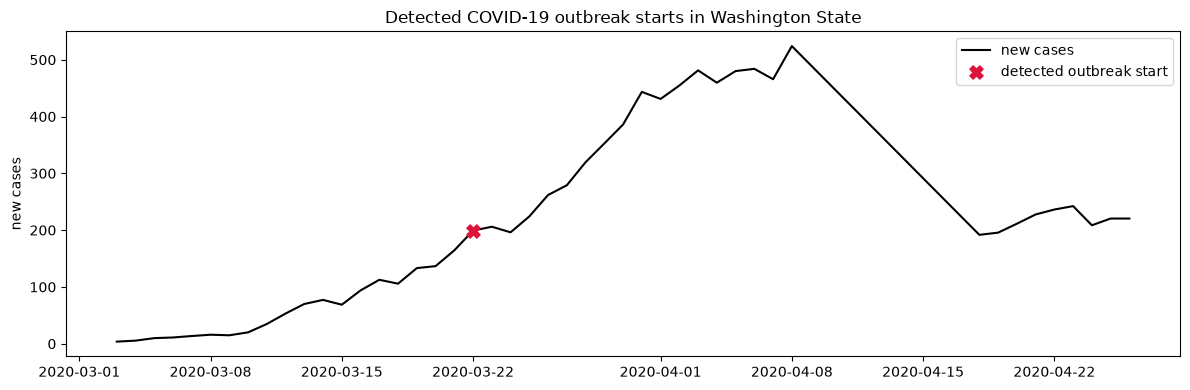

In [3]:
def detect_outbreak_starts(alpha, run_length=10):
    """Mark the first day after sustained growth; reset after sustained decline."""
    starts = np.zeros(len(alpha), dtype=bool)
    active = False
    for day in range(run_length - 1, len(alpha)):
        recent = alpha[day - run_length + 1:day + 1]
        sustained_growth = np.all(recent > 1)
        sustained_decline = np.all(recent < 1)
        if sustained_growth and not active:
            starts[day] = True
            active = True
        elif sustained_decline:
            active = False
    return starts

case_starts = detect_outbreak_starts(alpha_cases)
case_start_dates = df.loc[case_starts, 'date']
print('Detected case outbreak starts:')
for date in case_start_dates:
    print(' -', date.date())

plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['new_cases'], color='black', label='new cases')
plt.scatter(
    df.loc[case_starts, 'date'],
    df.loc[case_starts, 'new_cases'],
    color='crimson', marker='X', s=90, zorder=3, label='detected outbreak start',
)
plt.title('Detected COVID-19 outbreak starts in Washington State')
plt.ylabel('new cases')
plt.legend()
plt.tight_layout()
plt.show()


## Step 3: multi-trace early warning

> *Repeat the alpha + outbreak detection for every trace. For each trace, report how many*
> *days its first outbreak leads (negative) or lags (positive) the case-count outbreak,*
> *and redo the 6-panel plot with each trace's starts marked.*


,trace,first outbreak start,lead/lag vs cases (days)
0,new_cases,2020-03-22,0.0
1,upToDate,2020-03-22,0.0
2,cdc_ili,None,NaN
3,Twitter_RelatedTweets,2020-03-22,0.0
4,google_fever,2020-03-22,0.0
5,Kinsa_AnomalousFeverAbsolute,2020-03-30,8.0


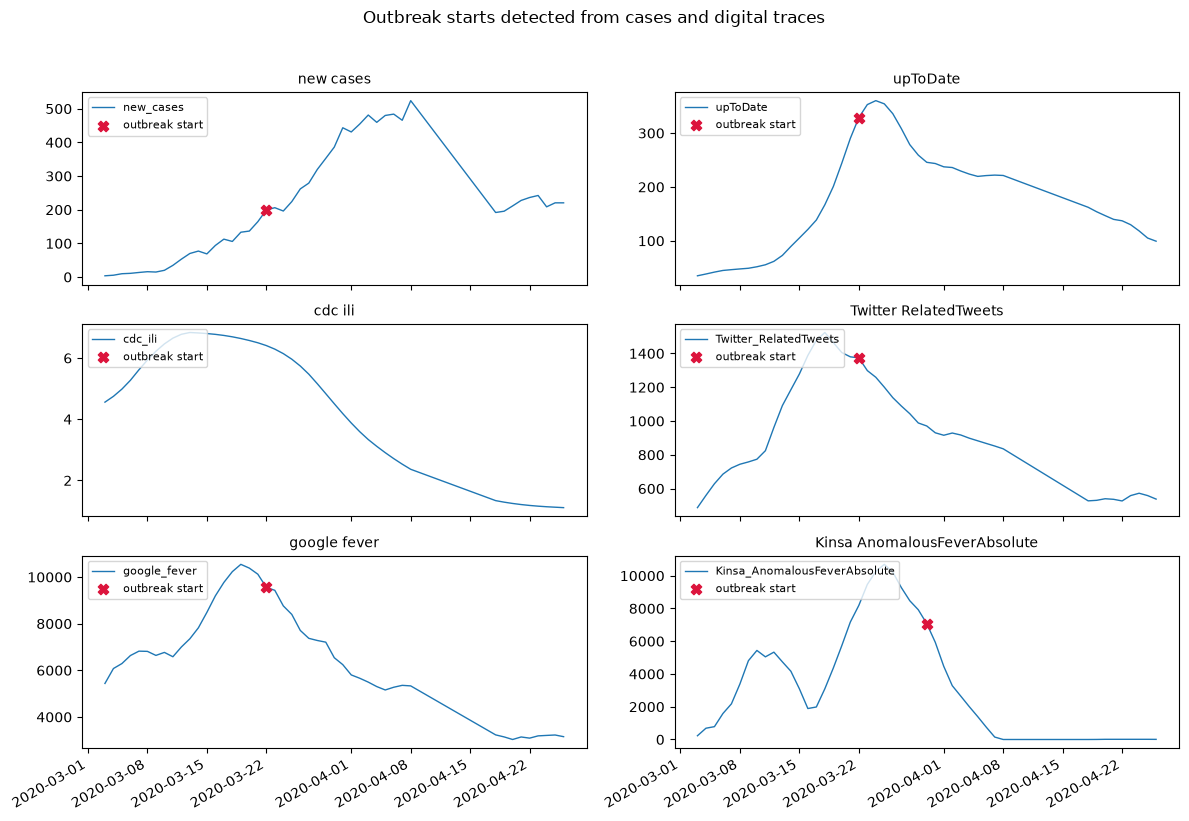

In [4]:
trace_results = []
first_case_start = np.flatnonzero(case_starts)[0] if case_starts.any() else None
trace_starts = {}

for trace in TRACES:
    starts = detect_outbreak_starts(growth_alpha(df[trace]))
    trace_starts[trace] = starts
    first_start = np.flatnonzero(starts)
    first_start = first_start[0] if len(first_start) else None
    lead_lag = None if first_start is None or first_case_start is None else first_start - first_case_start
    trace_results.append({
        'trace': trace,
        'first outbreak start': df['date'].iloc[first_start].date() if first_start is not None else None,
        'lead/lag vs cases (days)': lead_lag,
    })

lead_lag_table = pd.DataFrame(trace_results)
display(lead_lag_table)

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for ax, trace in zip(axes.ravel(), TRACES):
    ax.plot(df['date'], df[trace], color='C0', linewidth=1, label=trace)
    starts = trace_starts[trace]
    ax.scatter(
        df.loc[starts, 'date'], df.loc[starts, trace],
        color='crimson', marker='X', s=55, zorder=3, label='outbreak start',
    )
    ax.set_title(trace.replace('_', ' '), fontsize=10)
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Outbreak starts detected from cases and digital traces', y=1.02)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Reflection

- You described a detector; the agent wrote the sliding-window regression and the state
  machine.
- The judgment stayed with you: is the alarm early, and is it firing on signal or noise?
- **Next:** Mauricio's COVID research talk, then Day 3, bring your own problem.
